In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

movies = pd.read_csv('../data/raw/movies.csv')
ratings = pd.read_csv('../data/raw/ratings.csv')

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

movies.head()

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [8]:
print("Movies missing values:\n", movies.isnull().sum())
print("\nRatings missing values:\n", ratings.isnull().sum())

Movies missing values:
 movieId    0
title      0
genres     0
dtype: int64

Ratings missing values:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


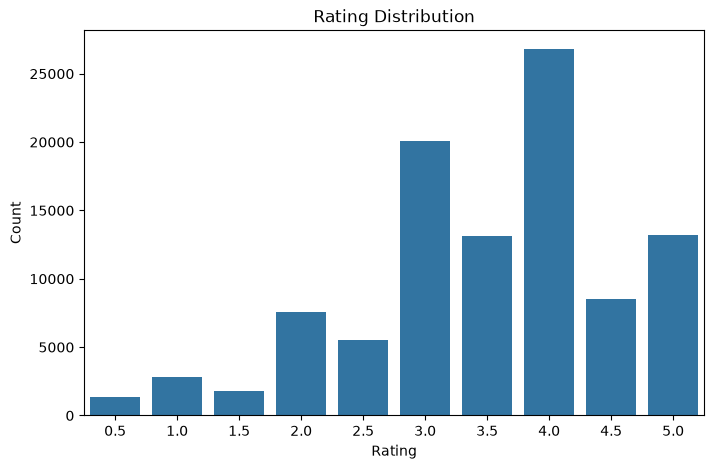

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=ratings)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [10]:
# Genres ko split karke unique genres nikalo
all_genres = movies['genres'].str.split('|').explode()
print("Unique genres:", all_genres.nunique())
print("\nTop genres:\n", all_genres.value_counts().head(10))

Unique genres: 20

Top genres:
 genres
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779
Name: count, dtype: int64


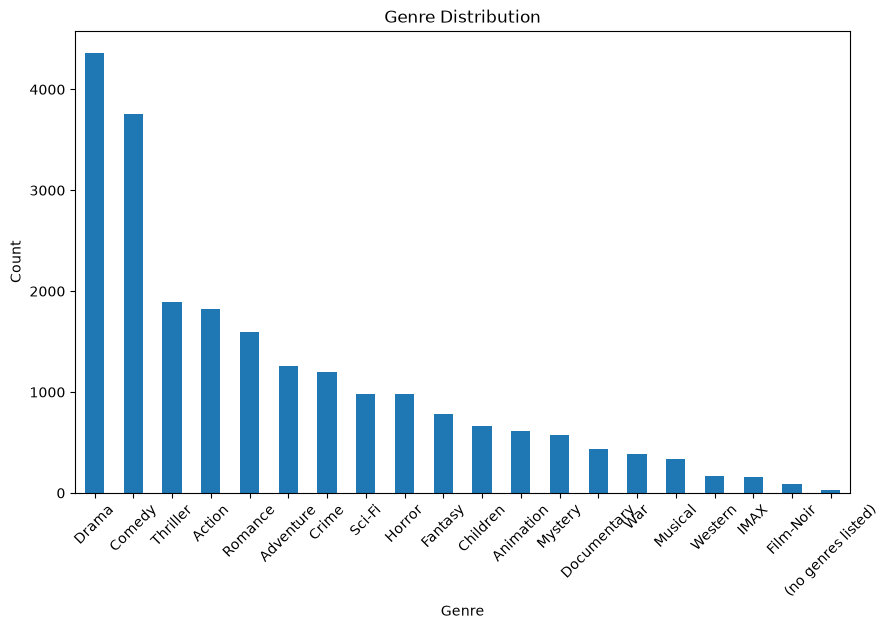

In [11]:
plt.figure(figsize=(10,6))
all_genres.value_counts().plot(kind='bar')
plt.title('Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [12]:
all_genres = movies['genres'].str.split('|').explode()
print("Unique genres:", all_genres.nunique())
print("\nTop genres:\n", all_genres.value_counts().head(10))

Unique genres: 20

Top genres:
 genres
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779
Name: count, dtype: int64


In [13]:
# Har user ne kitni movies rate ki
user_activity = ratings.groupby('userId')['rating'].count()
print("Users:", user_activity.shape[0])
print("Avg ratings per user:", user_activity.mean())
print("Min:", user_activity.min(), "Max:", user_activity.max())

# Har movie ko kitni baar rate kiya gaya
movie_activity = ratings.groupby('movieId')['rating'].count()
print("\nMovies:", movie_activity.shape[0])
print("Avg ratings per movie:", movie_activity.mean())
print("Min:", movie_activity.min(), "Max:", movie_activity.max())

Users: 610
Avg ratings per user: 165.30491803278687
Min: 20 Max: 2698

Movies: 9724
Avg ratings per movie: 10.369806663924312
Min: 1 Max: 329


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Pipe (|) ko space se replace karo taaki TF-IDF sahi tarike se genres ko words jaise treat kare
movies['genres_clean'] = movies['genres'].str.replace('|', ' ', regex=False)

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres_clean'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9742, 23)


In [16]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (9742, 9742)


In [17]:
# Movie title se index nikalne ke liye ek mapping banao
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def get_recommendations(title, cosine_sim=cosine_sim):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]  # top 10 (khud ko chhod ke)
    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices]

# Test karo
print(get_recommendations('Toy Story (1995)'))

1706                                          Antz (1998)
2355                                   Toy Story 2 (1999)
2809       Adventures of Rocky and Bullwinkle, The (2000)
3000                     Emperor's New Groove, The (2000)
3568                                Monsters, Inc. (2001)
6194                                     Wild, The (2006)
6486                               Shrek the Third (2007)
6948                       Tale of Despereaux, The (2008)
7760    Asterix and the Vikings (Astérix et les Viking...
8219                                         Turbo (2013)
Name: title, dtype: str


In [18]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split, cross_validate

# Surprise library ko data ka format chahiye: userId, movieId, rating
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Train-test split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# SVD model train karo
model = SVD()
model.fit(trainset)

# Test set pe evaluate karo
predictions = model.test(testset)

from surprise import accuracy
accuracy.rmse(predictions)

RMSE: 0.8806


np.float64(0.8806456590937132)

In [19]:
# Kisi bhi userId aur movieId ke liye prediction test karo
user_id = 1
movie_id = 1  # Toy Story

pred = model.predict(user_id, movie_id)
print(pred)

user: 1          item: 1          r_ui = None   est = 4.48   {'was_impossible': False}


In [20]:
def get_collab_recommendations(user_id, n=10):
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].tolist()
    all_movie_ids = movies['movieId'].tolist()
    unrated_movies = [m for m in all_movie_ids if m not in rated_movies]

    predictions = [(m, model.predict(user_id, m).est) for m in unrated_movies]
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    top_n = predictions[:n]
    top_movie_ids = [x[0] for x in top_n]
    return movies[movies['movieId'].isin(top_movie_ids)][['title', 'genres']]

print(get_collab_recommendations(1))

                                                 title  \
277                   Shawshank Redemption, The (1994)   
474                                Blade Runner (1982)   
602  Dr. Strangelove or: How I Learned to Stop Worr...   
819                        Fish Called Wanda, A (1988)   
903  Good, the Bad and the Ugly, The (Buono, il bru...   
906                          Lawrence of Arabia (1962)   
941                                       Glory (1989)   
948                   Femme Nikita, La (Nikita) (1990)   
971                                      Patton (1970)   
987                          This Is Spinal Tap (1984)   

                            genres  
277                    Crime|Drama  
474         Action|Sci-Fi|Thriller  
602                     Comedy|War  
819                   Comedy|Crime  
903       Action|Adventure|Western  
906            Adventure|Drama|War  
941                      Drama|War  
948  Action|Crime|Romance|Thriller  
971                      Dra

In [22]:
def hybrid_recommendations(user_id, title, n=10, content_weight=0.5, collab_weight=0.5):
    idx = indices[title]
    input_movie_id = movies.iloc[idx]['movieId']  # input movie ka ID save karo
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    hybrid_scores = []
    for i, content_score in sim_scores:
        movie_id = movies.iloc[i]['movieId']
        if movie_id == input_movie_id:  # khud ko explicitly skip karo
            continue
        collab_score = model.predict(user_id, movie_id).est / 5.0
        combined = (content_weight * content_score) + (collab_weight * collab_score)
        hybrid_scores.append((i, combined))
    
    hybrid_scores = sorted(hybrid_scores, key=lambda x: x[1], reverse=True)
    hybrid_scores = hybrid_scores[:n]  # ab position 0 se lena safe hai
    
    movie_indices = [i[0] for i in hybrid_scores]
    return movies[['title', 'genres']].iloc[movie_indices]

# Test karo
print(hybrid_recommendations(user_id=1, title='Toy Story (1995)'))

                                                  title  \
9430                                       Moana (2016)   
3568                              Monsters, Inc. (2001)   
6944                 Ponyo (Gake no ue no Ponyo) (2008)   
2355                                 Toy Story 2 (1999)   
1505                         Black Cauldron, The (1985)   
8900                                  Inside Out (2015)   
5546  Kiki's Delivery Service (Majo no takkyûbin) (1...   
8219                                       Turbo (2013)   
3000                   Emperor's New Groove, The (2000)   
1706                                        Antz (1998)   

                                                 genres  
9430        Adventure|Animation|Children|Comedy|Fantasy  
3568        Adventure|Animation|Children|Comedy|Fantasy  
6944               Adventure|Animation|Children|Fantasy  
2355        Adventure|Animation|Children|Comedy|Fantasy  
1505               Adventure|Animation|Children|Fantasy  
89

In [23]:
import pickle

# Models aur data save karo
with open('../models/tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)

with open('../models/cosine_sim.pkl', 'wb') as f:
    pickle.dump(cosine_sim, f)

with open('../models/svd_model.pkl', 'wb') as f:
    pickle.dump(model, f)

movies.to_pickle('../models/movies_df.pkl')
ratings.to_pickle('../models/ratings_df.pkl')

print("All models saved!")

All models saved!
